In [12]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------- MERGE ----------------
def merge_sorted_lists(list1, list2, index):
    N1, N2 = list1.shape[0], list2.shape[0]
    dim = list1.shape[1]

    final_list = np.zeros((N1 + N2, dim))

    j1 = j2 = j = 0

    while j1 < N1 and j2 < N2:
        if list1[j1, index] < list2[j2, index]:
            final_list[j] = list1[j1]
            j1 += 1
        else:
            final_list[j] = list2[j2]
            j2 += 1
        j += 1

    while j1 < N1:
        final_list[j] = list1[j1]
        j1 += 1
        j += 1

    while j2 < N2:
        final_list[j] = list2[j2]
        j2 += 1
        j += 1

    return final_list


# ---------------- MERGE SORT ----------------
def merge_sort(locations, index):
    N = locations.shape[0]

    if N == 1:
        return locations

    N_left = N // 2

    left = locations[:N_left]
    right = locations[N_left:]

    left_sorted = merge_sort(left, index)
    right_sorted = merge_sort(right, index)

    return merge_sorted_lists(left_sorted, right_sorted, index)


# ---------------- KD SORT ----------------
def get_kd_tree_sorted(locations, index=0):
    N, dims = locations.shape

    if N == 1:
        return locations

    axis = index % dims

    # Sort along current axis
    locations = merge_sort(locations, axis)

    N_left = N // 2

    # Split
    left = locations[:N_left]
    right = locations[N_left:]

    # Recursive KD sorting
    left_sorted = get_kd_tree_sorted(left, index + 1)
    right_sorted = get_kd_tree_sorted(right, index + 1)

    return np.vstack((left_sorted, right_sorted))

In [13]:
# ---------------- PLOT ----------------
def plot_with_labels(x_sorted):
    plt.figure()

    plt.scatter(x_sorted[:, 0], x_sorted[:, 1])

    for i in range(x_sorted.shape[0]):
        plt.text(
            x_sorted[i, 0] + 0.02,
            x_sorted[i, 1] + 0.02,
            str(i),
            fontsize=9
        )

    plt.axhline(0)  # visualize splitting intuition
    plt.axvline(0)

    plt.title("KDTree-style Sorted Points")
    plt.grid()
    plt.show()

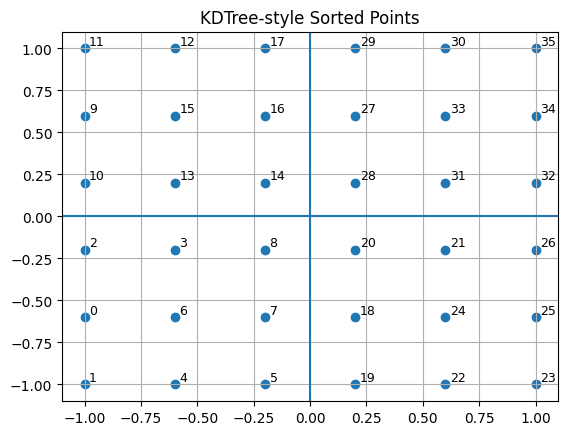

In [14]:
# ---------------- MAIN ----------------
if __name__ == "__main__":
    N = 64 # choose N as 2^(2m), where m is a positive integer to generate a perfect binary tree (all leaves are completely filled) of m levels in each dimension
    dim = 2

    # Uniform random points in [-1, 1]
    # x = np.random.uniform(-1, 1, (N, dim))

    # uniform points in [-1, 1] and then meshgrid to get in 2D
    grid_1d = np.linspace(-1, 1, int(N**(1/dim)))
    mesh = np.meshgrid(*([grid_1d] * dim))
    x = np.vstack([m.flatten() for m in mesh]).T

    # print("Original:\n", x)

    x_sorted = get_kd_tree_sorted(x, 0)

    # print("\nKDTree Sorted:\n", x_sorted)

    plot_with_labels(x_sorted)